<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/1.set_periods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Required Packages

In [1]:
# Import libraries for data manipulation, numerical computing, visualization, and signal processing
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computing
import matplotlib.pyplot as plt  # Plot generation
import seaborn as sns  # Statistical visualization
import os  # Operating system interface for file operations
from scipy.signal import find_peaks  # Signal processing for peak detection in time series

In [2]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

# Define Export Directory

In [3]:
# Set the output directory where processed results and visualizations will be saved
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Water Period Definitions"

# Import Water Level Data from HidroWeb

## Data Source: Agência Nacional de Águas (ANA) - Brazilian National Water Agency
**Superintendência de Gestão da Rede Hidrometeorológica (SGH)** - Hydrological Network Management  
**Sistema de Informações Hidrológicas (SIH)** - Hydrological Information System - Web Version

## Data Quality Indicators (from HidroWeb)
- **Consistency Level (NivelConsistencia):** 1 = Raw data, 2 = Quality-controlled data
- **Daily Average Flag (MediaDiaria):** Indicates if measurement is daily average or instantaneous. 0 = No, 1 = Yes
- **Water Level Measurement Type (TipoMedicaoCotas):** 1 = Staff gauge, 2 = Automatic gauge, 3 = Data Logger, 5 = SMS gauge
- **Data Status (Status):** 0 = Missing, 1 = Measured, 2 = Estimated, 3 = Questionable, 4 = Dry gauge

### Óbidos Water Level Station - Water Level Data  
**Station Code: 17050001** - Óbidos is located on the Amazon River and serves as a reference monitoring point

In [4]:
# Set the directory path where raw HidroWeb water level data files are stored
data_directory = "C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/HidroWeb"

In [5]:
# Load and process Óbidos water level data (cotas)
# Remove duplicate records for the same date to ensure unique daily measurements
obidos = pd.read_csv(os.path.join(data_directory, '17050001_Cotas.csv')).drop_duplicates(subset=['Data'])

# Select relevant columns: station code, date, and daily water level statistics (max, min, mean)
obidos = obidos[['EstacaoCodigo', 'Data', 'Maxima', 'Minima', 'Media']].copy()

# Convert date column to datetime format (Brazilian format: day/month/year)
obidos['Data'] = pd.to_datetime(obidos['Data'], dayfirst=True)

# Add location identifier for later merging with other stations
obidos['location'] = "Óbidos"

# Sort by date and reset index for proper chronological ordering
obidos = obidos.sort_values(by='Data').reset_index(drop=True)

# Display the processed Óbidos dataframe
obidos

,EstacaoCodigo,Data,Maxima,Minima,Media,location
0,17050001,1968-02-01,NaN,NaN,NaN,Óbidos
1,17050001,1968-03-01,478.0,401.0,436.0,Óbidos
2,17050001,1968-04-01,570.0,478.0,521.0,Óbidos
3,17050001,1968-05-01,646.0,575.0,621.0,Óbidos
4,17050001,1968-06-01,648.0,583.0,617.0,Óbidos
...,...,...,...,...,...,...
673,17050001,2025-03-01,684.0,548.0,625.0,Óbidos
674,17050001,2025-04-01,758.0,686.0,724.0,Óbidos
675,17050001,2025-05-01,778.0,760.0,773.0,Óbidos
676,17050001,2025-06-01,778.0,764.0,772.0,Óbidos


### Curuai Water Level Station - Water Level Data  
**Station Code: 17060000** - Curuai is located in the floodplain and is the primary study area

In [6]:
# Load and process Curuai water level data (cotas)
# Remove duplicate records for the same date to ensure unique daily measurements
curuai = pd.read_csv(os.path.join(data_directory, '17060000_Cotas.csv')).drop_duplicates(subset=['Data'])

# Select relevant columns: station code, date, and daily water level statistics (max, min, mean)
curuai = curuai[['EstacaoCodigo', 'Data', 'Maxima', 'Minima', 'Media']].copy()

# Convert date column to datetime format (Brazilian format: day/month/year)
curuai['Data'] = pd.to_datetime(curuai['Data'], dayfirst=True)

# Add location identifier for later merging with other stations
curuai['location'] = "Curuai"

# Sort by date and reset index for proper chronological ordering
curuai = curuai.sort_values(by='Data').reset_index(drop=True)

# Display the processed Curuai dataframe
curuai

,EstacaoCodigo,Data,Maxima,Minima,Media,location
0,17060000,1982-09-01,789.0,609.0,711.0,Curuai
1,17060000,1982-10-01,NaN,NaN,NaN,Curuai
2,17060000,1982-11-01,NaN,NaN,NaN,Curuai
3,17060000,1982-12-01,590.0,489.0,540.0,Curuai
4,17060000,1983-01-01,693.0,597.0,649.0,Curuai
...,...,...,...,...,...,...
418,17060000,2018-11-01,461.0,418.0,431.0,Curuai
419,17060000,2018-12-01,682.0,465.0,569.0,Curuai
420,17060000,2019-01-01,805.0,683.0,747.0,Curuai
421,17060000,2019-02-01,904.0,805.0,848.0,Curuai


In [7]:
# Merge data from both stations (Óbidos and Curuai) by date
# Using right join to restrict the time period to when Curuai data is available
cotas = obidos.merge(curuai, on="Data", how='right', suffixes=('_obidos', '_curuai'))

# Display the merged dataframe
cotas

,EstacaoCodigo_obidos,Data,Maxima_obidos,Minima_obidos,Media_obidos,location_obidos,EstacaoCodigo_curuai,Maxima_curuai,Minima_curuai,Media_curuai,location_curuai
0,17050001,1982-09-01,514.0,315.0,425.0,Óbidos,17060000,789.0,609.0,711.0,Curuai
1,17050001,1982-10-01,308.0,142.0,217.0,Óbidos,17060000,NaN,NaN,NaN,Curuai
2,17050001,1982-11-01,176.0,143.0,155.0,Óbidos,17060000,NaN,NaN,NaN,Curuai
3,17050001,1982-12-01,311.0,184.0,246.0,Óbidos,17060000,590.0,489.0,540.0,Curuai
4,17050001,1983-01-01,409.0,318.0,366.0,Óbidos,17060000,693.0,597.0,649.0,Curuai
...,...,...,...,...,...,...,...,...,...,...,...
418,17050001,2018-11-01,162.0,90.0,112.0,Óbidos,17060000,461.0,418.0,431.0,Curuai
419,17050001,2018-12-01,407.0,170.0,301.0,Óbidos,17060000,682.0,465.0,569.0,Curuai
420,17050001,2019-01-01,529.0,410.0,473.0,Óbidos,17060000,805.0,683.0,747.0,Curuai
421,17050001,2019-02-01,634.0,530.0,577.0,Óbidos,17060000,904.0,805.0,848.0,Curuai


In [8]:
# Clean and reorganize the merged dataframe for visualization
# Reset index and remove rows with missing values
cotas = cotas.reset_index(drop=True).dropna()

# Select only the relevant water level columns
cotas = cotas[['Maxima_obidos', 'Minima_obidos', 'Media_obidos',
        'Maxima_curuai', 'Minima_curuai', 'Media_curuai']]

# Rename columns to more descriptive labels (in English)
cotas.columns = ['Max Óbidos', 'Min Óbidos', 'Mean Óbidos',
        'Max Curuai', 'Min Curuai', 'Mean Curuai']


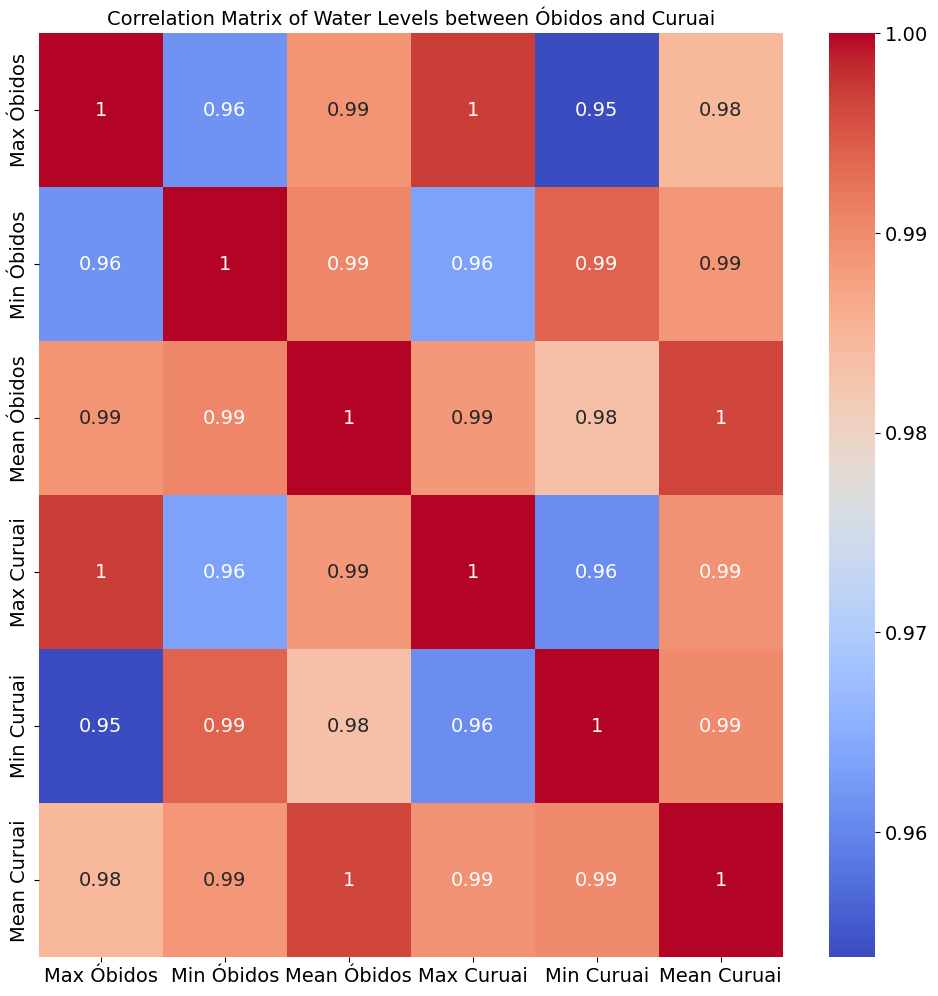

In [9]:
# Create and save correlation matrix heatmap showing relationships between water levels
plt.figure(figsize=(12, 12))
sns.heatmap(cotas.corr(), annot=True, cmap='coolwarm')
plt.savefig(os.path.join(exp_directory, 'correlation_matrix.png'), dpi=300)
plt.title('Correlation Matrix of Water Levels between Óbidos and Curuai')
plt.show()

In [10]:
# Calculate and display statistical summary of Óbidos water levels
# These statistics are used to define hydrological periods
print('Mean Óbidos water level: ', obidos["Media"].mean())
print('Standard deviation (Óbidos): ', obidos["Media"].std())
print('Upper threshold (mean + 1 std): ', obidos["Media"].mean() + (obidos["Media"].std()))
print('Lower threshold (mean - 1 std): ', obidos["Media"].mean() - (obidos["Media"].std()))

Mean Óbidos water level:  481.9778434268833
Standard deviation (Óbidos):  216.01084329172613
Upper threshold (mean + 1 std):  697.9886867186094
Lower threshold (mean - 1 std):  265.96700013515715


# Classify Hydrological Water Periods

In [11]:
# --- CONFIGURATION ---
# 1. Specify target DataFrame variable name here (default: obidos)
target_df = obidos  # <--- CHANGE THIS if your dataframe is named differently

# 2. Set column names for water level and date
col_level = 'Media'  # Column containing daily mean water level
col_date = 'Data'    # Column containing dates
# ---------------------

# Ensure dates are properly formatted as datetime objects
target_df[col_date] = pd.to_datetime(target_df[col_date])

# Detect peaks (High Water periods) and valleys (Low Water periods) in the water level time series
# distance=10 prevents detection of micro-fluctuations by ensuring peaks are at least 10 days apart
peaks_indices, _ = find_peaks(target_df[col_level], distance=10)
valleys_indices, _ = find_peaks(-target_df[col_level], distance=10)

# Extract high water period records
df_peaks = target_df.iloc[peaks_indices].copy()
df_peaks['water_period'] = 'HW'  # High Water classification

# Extract low water period records
df_valleys = target_df.iloc[valleys_indices].copy()
df_valleys['water_period'] = 'LW'  # Low Water classification

# Combine peak and valley points and sort chronologically
critical_points = pd.concat([df_peaks, df_valleys])
critical_points[col_date] = pd.to_datetime(critical_points[col_date])
critical_points = critical_points.sort_values(by=col_date).reset_index(drop=True)

# Calculate transition dates based on the midpoints between critical points
critical_points['next'] = critical_points['Data'].shift(-1)
critical_points['previous'] = critical_points['Data'].shift(+1)

# Define transition limits at 1/4 point between consecutive critical points
critical_points['lim_next'] = critical_points['Data'] + ((critical_points['next'] - critical_points['Data'])/4)
critical_points['lim_previous'] = critical_points['Data'] - ((critical_points['Data'] - critical_points['previous'])/4)

# Define hydrological periods based on transitions between high and low water
period_limits = []

for i in range(len(critical_points) - 1):
    start_date = critical_points.loc[i, 'lim_next']
    end_date = critical_points.loc[i+1, 'lim_previous']
    
    current_type = critical_points.loc[i, 'water_period']
    next_type = critical_points.loc[i+1, 'water_period']
    
    # Classify period based on transition type
    if current_type == 'LW' and next_type == 'HW':
        classification = "R"  # Rising period (Low Water → High Water)
    elif current_type == 'HW' and next_type == 'LW':
        classification = "F"  # Falling period (High Water → Low Water)
    else:
        # Handle transition or double peak cases
        classification = f"{current_type}_Transition"

    period_limits.append({
        'lim_previous': start_date,
        'lim_next': end_date,
        'water_period': classification,
    })

# Create DataFrame with period definitions
df_period_limits = pd.DataFrame(period_limits)

print("Period classification complete. Display of latest 20 classified periods:")
display(df_period_limits.tail(20))

Period classification complete. Display of latest 20 classified periods:


,lim_previous,lim_next,water_period
92,2015-07-09 06:00:00,2015-09-23 18:00:00,F
93,2015-12-24 06:00:00,2016-04-08 18:00:00,R
94,2016-07-09 06:00:00,2016-09-23 18:00:00,F
95,2016-12-16 06:00:00,2017-03-16 18:00:00,R
96,2017-06-08 06:00:00,2017-08-23 18:00:00,F
97,2017-11-30 18:00:00,2018-04-01 06:00:00,R
98,2018-07-09 06:00:00,2018-09-23 18:00:00,F
99,2018-12-24 00:00:00,2019-04-09 00:00:00,R
100,2019-07-09 06:00:00,2019-09-23 18:00:00,F
101,2019-12-24 06:00:00,2020-04-08 18:00:00,R


In [12]:
# Merge period limits with critical points to include all hydrological information
period_limits = df_period_limits.merge(critical_points[['lim_previous', 'lim_next', 'water_period']], 
                                       on=['lim_previous', 'lim_next', 'water_period'], how='outer')

In [13]:
# Ensure date columns are properly formatted as datetime objects for further processing
period_limits['lim_previous'] = pd.to_datetime(period_limits['lim_previous'])
period_limits['lim_next'] = pd.to_datetime(period_limits['lim_next'])

# Display the final period limits table
period_limits

,lim_previous,lim_next,water_period
0,NaT,1968-09-30 12:00:00,HW
1,1968-09-30 12:00:00,1969-08-01 12:00:00,F
2,1969-08-01 12:00:00,1970-02-07 18:00:00,LW
3,1970-02-07 18:00:00,1970-04-24 06:00:00,R
4,1970-04-24 06:00:00,1970-07-16 18:00:00,HW
...,...,...,...
220,2024-03-16 12:00:00,2024-06-08 06:00:00,HW
221,2024-06-08 06:00:00,2024-08-23 18:00:00,F
222,2024-08-23 18:00:00,2024-11-23 00:00:00,LW
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R


In [14]:

# Convert date columns to datetime format for proper temporal processing
period_limits['lim_next'] = pd.to_datetime(period_limits['lim_next'])
period_limits['lim_previous'] = pd.to_datetime(period_limits['lim_previous'])

# Sort by start date to ensure chronological order
period_limits = period_limits.sort_values(by='lim_next').reset_index(drop=True)

# Fill missing end dates with 3-month offset from start date
period_limits['lim_next'] = period_limits['lim_next'].fillna(
    period_limits['lim_previous'] + pd.DateOffset(months=3)
)

# Fill missing start dates with negative 3-month offset from end date
period_limits['lim_previous'] = period_limits['lim_previous'].fillna(
    period_limits['lim_next'] + pd.DateOffset(months=-3)
)

# Display last rows to verify data completeness
display(period_limits.tail())

,lim_previous,lim_next,water_period
220,2024-03-16 12:00:00,2024-06-08 06:00:00,HW
221,2024-06-08 06:00:00,2024-08-23 18:00:00,F
222,2024-08-23 18:00:00,2024-11-23 00:00:00,LW
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R
224,2025-03-09 00:00:00,2025-06-09 00:00:00,HW


In [15]:
# Define additional periods for recent data not covered by historical classification
fill_periods = {
    'lim_previous': ['2025-06-09 00:00:00', '2025-09-09 00:00:00', '2025-12-09 00:00:00'],
    "lim_next": ['2025-09-09 00:00:00', '2025-12-09 00:00:00', '2026-01-01 00:00:00'],
    'water_period': ['F', 'LW', "R"]  # F=Falling, LW=Low Water, R=Rising
}
fill_periods = pd.DataFrame(fill_periods)

# Append new periods to the dataframe and reset index
period_limits = pd.concat([period_limits, fill_periods]).reset_index(drop=True)

# Ensure date columns are properly formatted as datetime
period_limits['lim_previous'] = pd.to_datetime(period_limits['lim_previous'])
period_limits['lim_next'] = pd.to_datetime(period_limits['lim_next'])

# Extract year and month from start date for later reference
period_limits['year'] = period_limits['lim_next'].dt.year
period_limits['month'] = period_limits['lim_next'].dt.month

# period_limits = period_limits.loc[(period_limits['lim_previous'] >= "1984-01-01")].copy().reset_index(drop=True)

# Display the complete period limits table
period_limits

,lim_previous,lim_next,water_period,year,month
0,1968-06-30 12:00:00,1968-09-30 12:00:00,HW,1968,9
1,1968-09-30 12:00:00,1969-08-01 12:00:00,F,1969,8
2,1969-08-01 12:00:00,1970-02-07 18:00:00,LW,1970,2
3,1970-02-07 18:00:00,1970-04-24 06:00:00,R,1970,4
4,1970-04-24 06:00:00,1970-07-16 18:00:00,HW,1970,7
...,...,...,...,...,...
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R,2025,3
224,2025-03-09 00:00:00,2025-06-09 00:00:00,HW,2025,6
225,2025-06-09 00:00:00,2025-09-09 00:00:00,F,2025,9
226,2025-09-09 00:00:00,2025-12-09 00:00:00,LW,2025,12


In [16]:
# Export the period limits table to CSV file for use in subsequent analysis notebooks
period_limits.to_csv(os.path.join(exp_directory, 'water_period_limits.csv'))

In [17]:
# Prepare for water period classification of all daily water level records
# Ensure date columns are properly formatted
period_limits['lim_previous'] = pd.to_datetime(period_limits['lim_previous'])
period_limits['lim_next'] = pd.to_datetime(period_limits['lim_next'])

# Define function to classify each date into its corresponding hydrological period
def find_period(date_val):
    """
    Match a given date to its corresponding water period (Rising, Falling, High Water, Low Water).
    
    Parameters:
    - date_val: Single date value to classify
    
    Returns:
    - water_period: Classification of the water period for the given date, or None if not matched
    """
    # Filter period limits to find the matching row where the date falls within the period boundaries
    match = period_limits[
        (period_limits['lim_previous'] <= date_val) & 
        (period_limits['lim_next'] >= date_val)
    ]
    
    # If a match is found, return the water period classification
    if not match.empty:
        return match.iloc[0]['water_period']
    # Handle boundary cases for dates before the first period
    elif date_val <= period_limits['lim_next'].iloc[0]:
        return period_limits['water_period'].iloc[0]
    # Handle boundary cases for dates after the last period
    elif date_val >= period_limits['lim_previous'].iloc[-1]:
        return period_limits['water_period'].iloc[-1]
    else:
        return None

# Apply the water period classification function to all dates in the Óbidos time series
obidos['water_period'] = obidos['Data'].apply(find_period)

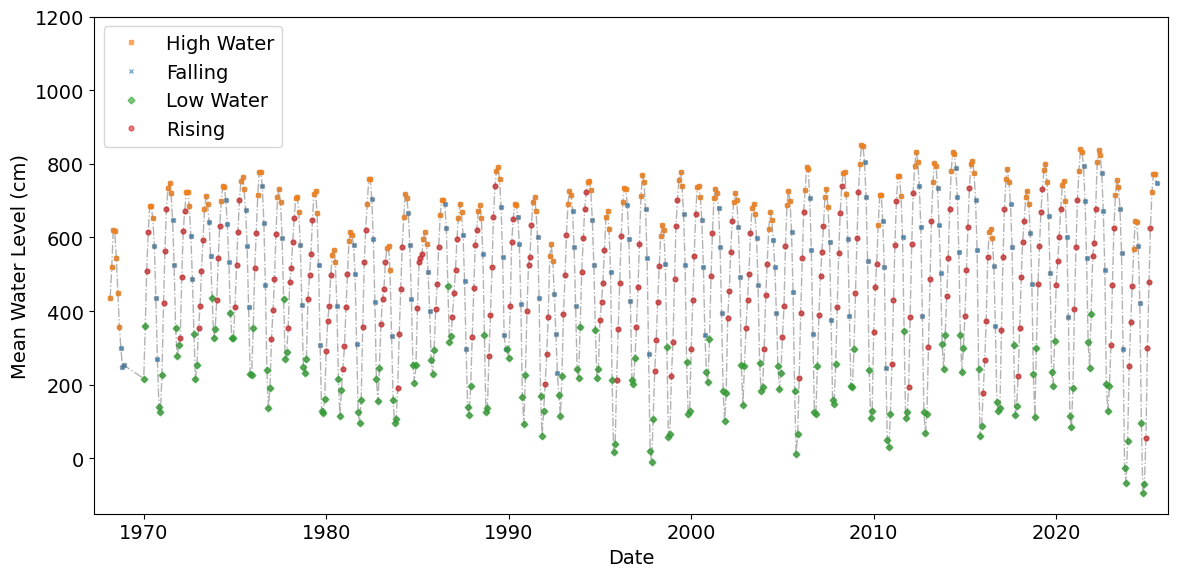

In [18]:
# Visualize water level time series with hydrological period classification at Óbidos station
# This shows how water levels follow similar patterns across different hydrological periods

fig, ax = plt.subplots(figsize=(12, 6))

# Plot all data points as gray line with low opacity to show overall trend
ax.plot(obidos['Data'], obidos['Media'],
        color='#7f7f7f', marker="o", markersize=3, linestyle='-.', linewidth=1, alpha=0.6)

# Define period names and visualization properties
period = obidos['water_period'].unique()
period_names = {'R': "Rising", 'F': "Falling", "HW": "High Water", "LW": "Low Water"}
period_markers = {'R': "o", 'F': "x", "HW": "s", "LW": "D"}
period_colors = {"F": '#1f77b4', "HW": '#ff7f0e', "LW": '#2ca02c', "R": '#d62728'}

# Plot each period separately with distinct colors and markers for easy identification
for p in range(len(period)):
    data = obidos.loc[obidos['water_period'] == period[p]].copy()
    ax.plot(data['Data'], data['Media'], color=period_colors[period[p]], 
            marker=period_markers[period[p]], markersize=3.5, linestyle='None', 
            alpha=0.6, label=f'{period_names[period[p]]}')

# Configure plot appearance and labels
ax.set_xlabel('Date')
ax.set_ylabel('Mean Water Level (cm)')
ax.legend(loc='upper left')
ax.set_ylim(-150, 1200)
ax.set_xlim(left=-1000, right=20500)

# Save and display the visualization
plt.tight_layout()
plt.savefig(os.path.join(exp_directory, f"periods.jpg"), dpi=300)
plt.show()
plt.close()

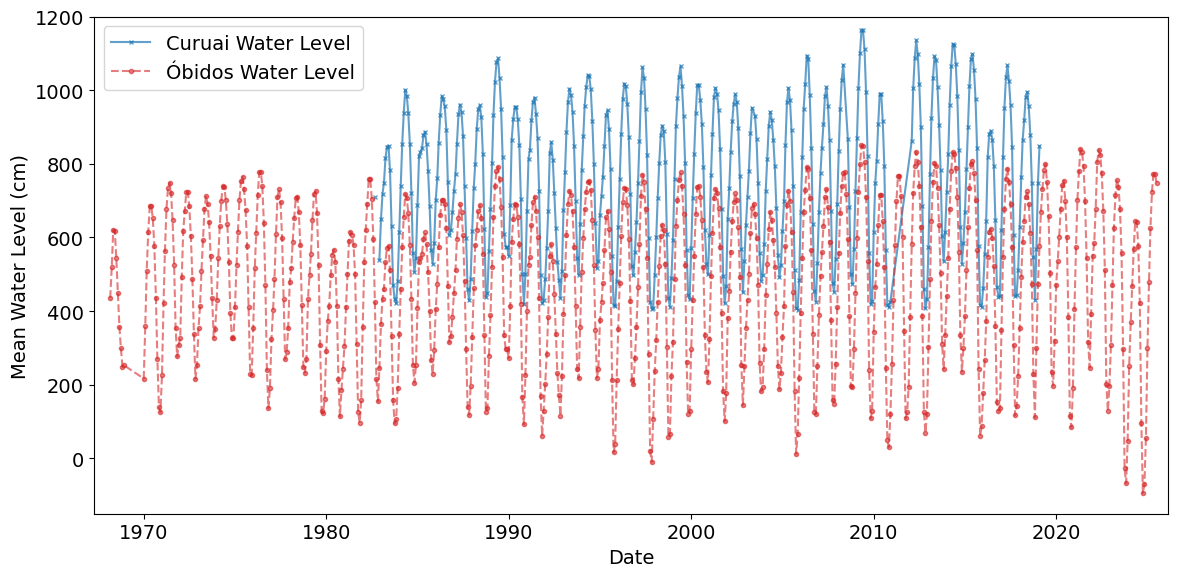

In [19]:
#comparar dados = seguem o mesmo padrão, aproximadamente
# grafico de linhas


fig, ax = plt.subplots(figsize=(12, 6))

    # Plot predictions
ax.plot(curuai['Data'], curuai['Media'],
            color= '#1f77b4',marker="x",markersize = 2.5,  linestyle='solid', linewidth=1.5, alpha=0.7, label='Curuai Water Level')
ax.plot(obidos['Data'], obidos['Media'],
            color='#d62728', marker="o",markersize = 3,linestyle='--', linewidth=1.5, alpha=0.6, label='Óbidos Water Level')


ax.set_xlabel('Date')
ax.set_ylabel('Mean Water Level (cm)')
ax.legend(loc='upper left')
ax.set_ylim(-150,1200)
ax.set_xlim(left = -1000,right=20500)

plt.tight_layout()
plt.savefig(os.path.join(exp_directory,f"time_series.jpg"),dpi=300)
plt.show()
plt.close()